In [1]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import sys

G = 9.80665

FDSN_CLIENT = Client("http://192.168.11.250:8080")

NETWORK = "GO"
STATION_ACC = "TBLG"
STATION_VEL = "TBLG"
CHANNEL_ACC = "HNE"
CHANNEL_VEL = "HHE"

# გამოყენება: python pga_calc.py "2024-07-22T08:08:09.660"
if len(sys.argv) > 1:
    origin_time_str = sys.argv[1]
else:
    origin_time_str = "2024-07-22T08:08:09.660"  # fallback/hardcode

ORIGIN_TIME = UTCDateTime("2025-12-18 09:26:27.460")
START_TIME = ORIGIN_TIME - 120
END_TIME = ORIGIN_TIME + 180

In [2]:
# --------------------------
# 1) პირდაპირი ACC არხებიდან
# --------------------------
acc_inventory = FDSN_CLIENT.get_stations(
    network=NETWORK,
    station=STATION_ACC,
    location="*",
    channel=CHANNEL_ACC,
    starttime=START_TIME,
    endtime=END_TIME,
    level="response"
)

acc_stream = FDSN_CLIENT.get_waveforms(
    NETWORK, STATION_ACC, "*", CHANNEL_ACC, START_TIME, END_TIME
)

acc_stream.detrend("linear")
acc_stream.detrend("demean")
acc_stream.remove_response(
    inventory=acc_inventory,
    output="ACC"
)

acc_stream.filter(
    "bandpass",
    freqmin=0.1,
    freqmax=10.0,
    corners=4,
    zerophase=True,
)

print("=== PGA from ACC channels (HN*) ===")
for tr in acc_stream:
    max_acc = np.max(np.abs(tr.data))
    max_g = max_acc / G
    pga_percent = max_g * 100   # %g
    print(f"{tr.id} : {max_g:.6f} g  PGA: ({pga_percent:.2f} %g)")

=== PGA from ACC channels (HN*) ===
GO.TBLG.10.HNE : 0.007077 g  PGA: (0.71 %g)


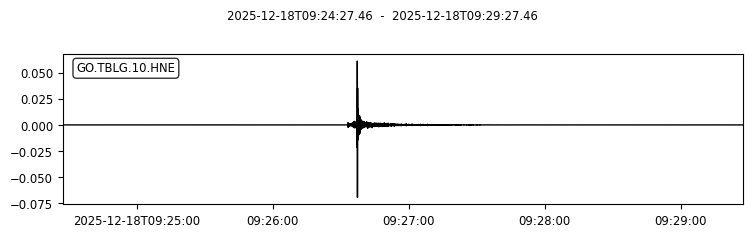

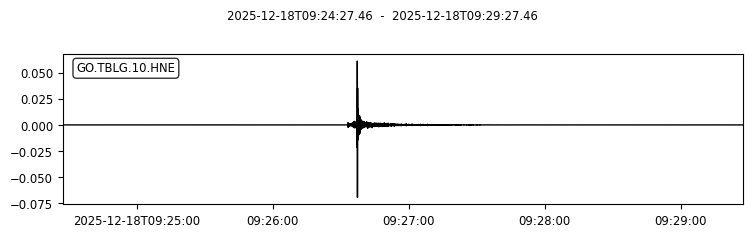

In [9]:
# 👉 აქვე ვხატავთ ACC არხებს ( უკვე response-მოხსნილი + გაფილტრული )
acc_stream.plot(equal_scale=True)

In [4]:
# --------------------------
# 2) VEL არხებიდან დიფერენცირებით
# --------------------------
vel_inventory = FDSN_CLIENT.get_stations(
    network=NETWORK,
    station=STATION_VEL,
    location="*",
    channel=CHANNEL_VEL,
    starttime=START_TIME,
    endtime=END_TIME,
    level="response"
)

vel_stream = FDSN_CLIENT.get_waveforms(
    NETWORK, STATION_VEL, "*", CHANNEL_VEL, START_TIME, END_TIME
)

vel_stream.remove_response(
    inventory=vel_inventory,
    output="VEL"
)

vel_stream.filter("bandpass", freqmin=0.1, freqmax=10.0, corners=4, zerophase=True)

# ვაკეთებთ ACC ვერსიას – ცალკე Stream
vel_acc_stream = vel_stream.copy()
for tr in vel_acc_stream:
    tr.differentiate()  # ახლა ეს უკვე ACC (m/s²)-ია

# აქედან ვთვლით PGA-ს
for tr in vel_acc_stream:
    max_acc = np.max(np.abs(tr.data))
    max_g = max_acc / G
    pga_percent = max_g * 100
    print(f"{tr.id} -> PGA: {max_g:.6f} g ({pga_percent:.2f} %g)")

GO.TBLG.00.HHE -> PGA: 0.001727 g (0.17 %g)


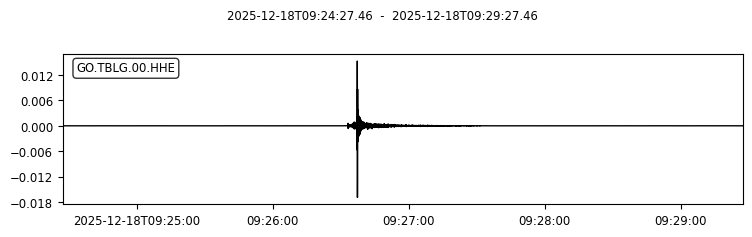

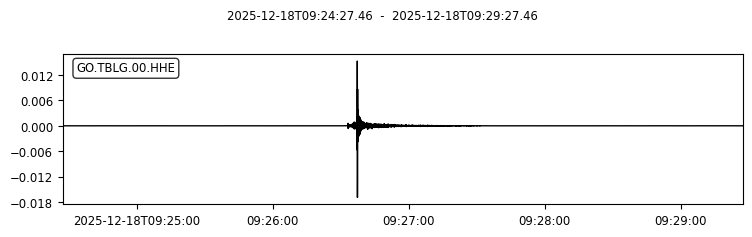

In [5]:
# 👉 და ესენი – VEL→ACC დიფერენცირებული სიგნალები
vel_acc_stream.plot(equal_scale=True)

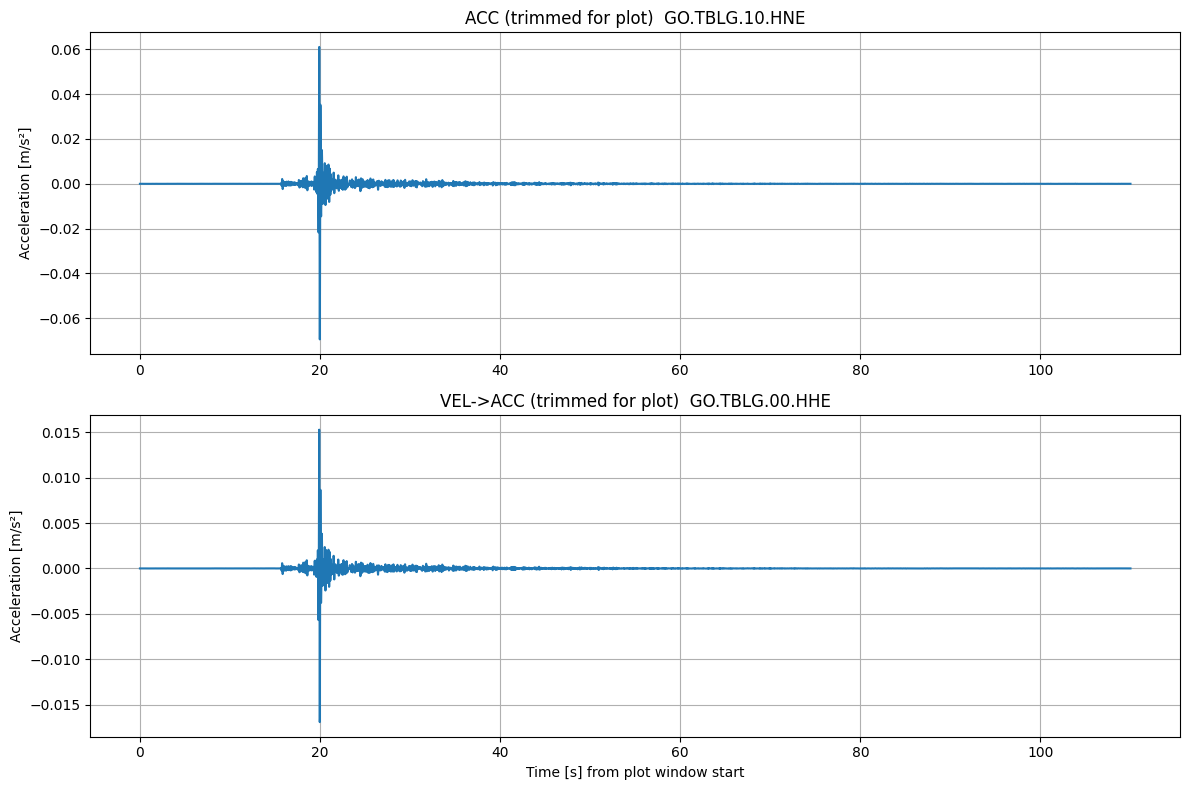

In [6]:
# --- define plot window ---
import matplotlib.pyplot as plt
plot_start = ORIGIN_TIME - 10
plot_end   = ORIGIN_TIME + 100

# --- choose one ACC trace and one VEL->ACC trace for plotting ---
tr_acc = acc_stream[0]        # or use .select(...) if you want a specific component
tr_vel_acc = vel_acc_stream[0]

# --- make trimmed copies ONLY for plotting (now on Trace objects) ---
tr_acc_cut = tr_acc.copy().trim(plot_start, plot_end)
tr_vel_cut = tr_vel_acc.copy().trim(plot_start, plot_end)

# --- time vectors for trimmed traces ---
t_acc = np.arange(tr_acc_cut.stats.npts) / tr_acc_cut.stats.sampling_rate
t_vel = np.arange(tr_vel_cut.stats.npts) / tr_vel_cut.stats.sampling_rate

# --- plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(t_acc, tr_acc_cut.data)
ax1.set_title(f"ACC (trimmed for plot)  {tr_acc.id}")
ax1.set_ylabel("Acceleration [m/s²]")
ax1.grid(True)

ax2.plot(t_vel, tr_vel_cut.data)
ax2.set_title(f"VEL->ACC (trimmed for plot)  {tr_vel_acc.id}")
ax2.set_xlabel("Time [s] from plot window start")
ax2.set_ylabel("Acceleration [m/s²]")
ax2.grid(True)

plt.tight_layout()
plt.show()


Using pair: GO.TBLG.10.HNE  &  GO.TBLG.00.HHE
Cross Correlation = 0.9938; Sample Shift = 0; Time Shift = 0.000 s


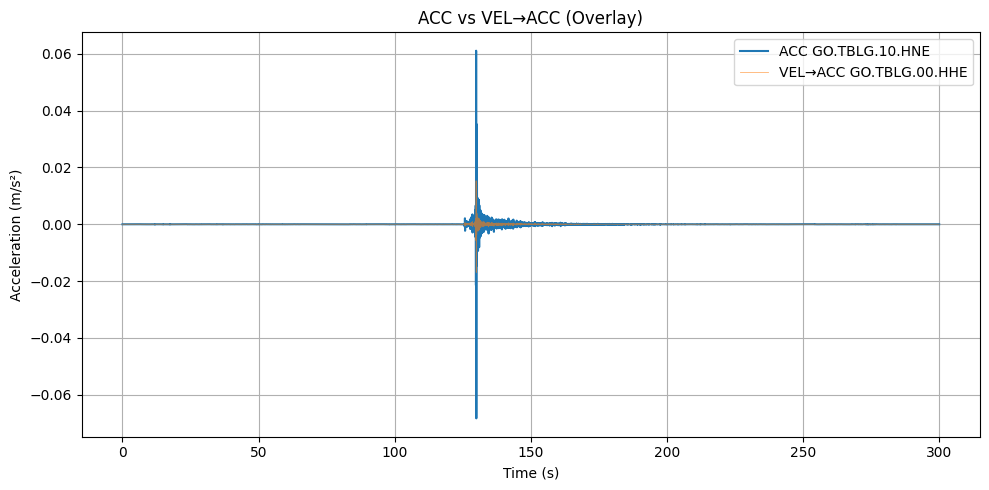

In [7]:
import numpy as np
from obspy.signal.cross_correlation import correlate, xcorr_max

# print("Origin time: 2024-07-17 02:09:27.670; Latitude: 41.4261; Longitude: 46.001; Depth(km): 21; Nearest station(km): 13" )
# 1) ავაწყოთ dictionary ACC ტრეისებისთვის: გასაღები = კომპონენტი (Z / N / E)
acc_dict = {}
for tr in acc_stream:
    key = tr.stats.channel[-1]  # Z / N / E
    acc_dict[key] = tr

# 2) ავირჩიოთ ერთი ACC / VEL->ACC წყვილი, მაგალითად შესაბამისი კომპონენტით
pair_found = False
for tr_vel_acc in vel_acc_stream:
    key = tr_vel_acc.stats.channel[-1]
    if key not in acc_dict:
        continue

    tr_acc = acc_dict[key]
    pair_found = True
    print(f"Using pair: {tr_acc.id}  &  {tr_vel_acc.id}")
    break

if not pair_found:
    print("No matching ACC / VEL->ACC pair found for plotting.")
else:
    # 3) დავახარისხოთ sampling_rate (გათანაბრება, თუ არ ემთხვევა)
    if tr_vel_acc.stats.sampling_rate != tr_acc.stats.sampling_rate:
        tr_acc = tr_acc.copy()
        tr_acc.interpolate(tr_vel_acc.stats.sampling_rate)

    fs = tr_acc.stats.sampling_rate
    # print(f"Sampling rate: {fs} Hz")

    # 4) საერთო დროის ფანჯარა
    t_start = max(tr_acc.stats.starttime, tr_vel_acc.stats.starttime)
    t_end   = min(tr_acc.stats.endtime,   tr_vel_acc.stats.endtime)

    tr_acc_c = tr_acc.copy().trim(t_start, t_end, pad=True, fill_value=0)
    tr_vel_c = tr_vel_acc.copy().trim(t_start, t_end, pad=True, fill_value=0)

    # 5) მონაცემები float64-ზე
    data_acc = tr_acc_c.data.astype("float64")
    data_vel = tr_vel_c.data.astype("float64")

    # 6) დროის ვექტორი პლოტისთვის
    n = len(data_acc)
    time = np.linspace(0, (n - 1) / fs, n)

    # 7) Cross-correlation (მხოლოდ ბეჭდვისთვის)
    max_shift_sec = 10
    max_shift = int(max_shift_sec * fs)

    cc = correlate(data_acc, data_vel, shift=max_shift)
    sample_shift, corr_coeff = xcorr_max(cc)
    time_shift = sample_shift / fs

    print(f"Cross Correlation = {corr_coeff:.4f}; Sample Shift = {sample_shift}; Time Shift = {time_shift:.3f} s")

    # 8) მხოლოდ ერთი პლოტი: ACC vs VEL->ACC
    plt.figure(figsize=(10, 5))
    plt.plot(time, data_acc, label=f"ACC {tr_acc.id}", linewidth=1.5)
    plt.plot(time, data_vel, label=f"VEL→ACC {tr_vel_acc.id}", alpha=0.6, linewidth=0.6)
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.title("ACC vs VEL→ACC (Overlay)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Using pair: GO.TBLG.10.HNE  &  GO.TBLG.00.HHE
Cross Correlation = 0.9938; Sample Shift = 0; Time Shift = 0.000 s


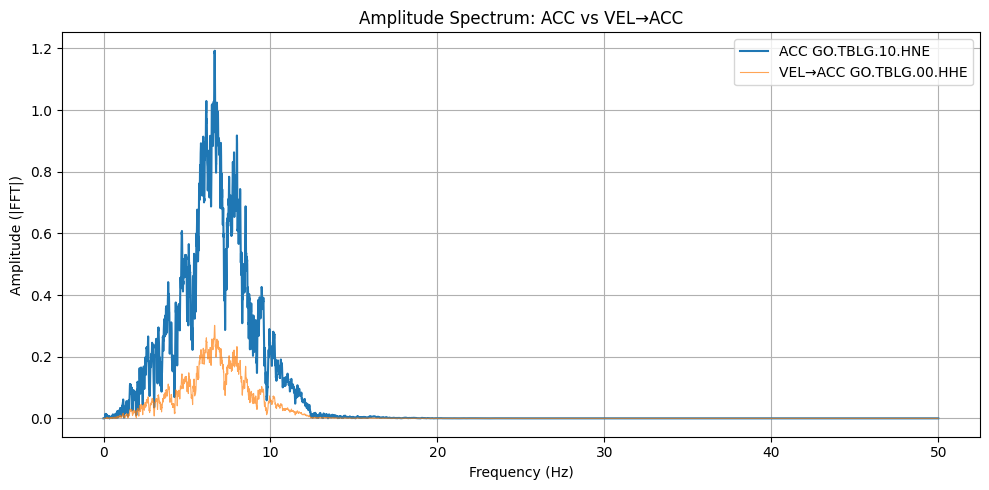

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.signal.cross_correlation import correlate, xcorr_max

# print("Origin time: 2024-07-17 02:09:27.670; Latitude: 41.4261; Longitude: 46.001; Depth(km): 21; Nearest station(km): 13" )

# 1) ავაწყოთ dictionary ACC ტრეისებისთვის: გასაღები = კომპონენტი (Z / N / E)
acc_dict = {}
for tr in acc_stream:
    key = tr.stats.channel[-1]  # Z / N / E
    acc_dict[key] = tr

# 2) ავირჩიოთ ერთი ACC / VEL->ACC წყვილი, მაგალითად შესაბამისი კომპონენტით
pair_found = False
for tr_vel_acc in vel_acc_stream:
    key = tr_vel_acc.stats.channel[-1]
    if key not in acc_dict:
        continue

    tr_acc = acc_dict[key]
    pair_found = True
    print(f"Using pair: {tr_acc.id}  &  {tr_vel_acc.id}")
    break

if not pair_found:
    print("No matching ACC / VEL->ACC pair found for plotting.")
else:
    # 3) დავახარისხოთ sampling_rate (გათანაბრება, თუ არ ემთხვევა)
    if tr_vel_acc.stats.sampling_rate != tr_acc.stats.sampling_rate:
        tr_acc = tr_acc.copy()
        tr_acc.interpolate(tr_vel_acc.stats.sampling_rate)

    fs = tr_acc.stats.sampling_rate  # sampling rate [Hz]

    # 4) საერთო დროის ფანჯარა
    t_start = max(tr_acc.stats.starttime, tr_vel_acc.stats.starttime)
    t_end   = min(tr_acc.stats.endtime,   tr_vel_acc.stats.endtime)

    tr_acc_c = tr_acc.copy().trim(t_start, t_end, pad=True, fill_value=0)
    tr_vel_c = tr_vel_acc.copy().trim(t_start, t_end, pad=True, fill_value=0)

    # 5) მონაცემები float64-ზე
    data_acc = tr_acc_c.data.astype("float64")
    data_vel = tr_vel_c.data.astype("float64")

    # (სურვილის შემთხვევაში) საშუალოს გამოკლება ლიკેજის შესამცირებლად
    data_acc -= data_acc.mean()
    data_vel -= data_vel.mean()

    # 6) Cross-correlation (თუ გინდა, რომ დარჩეს ბეჭდვისთვის)
    max_shift_sec = 10
    max_shift = int(max_shift_sec * fs)

    cc = correlate(data_acc, data_vel, shift=max_shift)
    sample_shift, corr_coeff = xcorr_max(cc)
    time_shift = sample_shift / fs

    print(f"Cross Correlation = {corr_coeff:.4f}; Sample Shift = {sample_shift}; Time Shift = {time_shift:.3f} s")

    # 7) FFT-ს გამოთვლა
    n = len(data_acc)  # ორივეს უკვე ერთი და იგივე სიგრძე აქვს
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)        # [Hz]
    fft_acc = np.fft.rfft(data_acc)
    fft_vel = np.fft.rfft(data_vel)

    amp_acc = np.abs(fft_acc)
    amp_vel = np.abs(fft_vel)

    # 8) სპექტრის პლოტი (ACC vs VEL->ACC)
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, amp_acc, label=f"ACC {tr_acc.id}", linewidth=1.5)
    plt.plot(freqs, amp_vel, label=f"VEL→ACC {tr_vel_acc.id}", alpha=0.7, linewidth=0.8)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (|FFT|)")
    plt.title("Amplitude Spectrum: ACC vs VEL→ACC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
